# Shopping Dataset Analysis using Pandas

Objective:
Perform data exploration, cleaning, feature engineering, and visualization on the shopping dataset.

1.call imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

2.create dataframe from csv

In [3]:
df = pd.read_csv("../data/combined_dataset.csv")

print(df.shape)
df.head()

(1000, 24)


,product_id,title,product_description,rating,ratings_count,initial_price,discount,final_price,currency,images,...,amount_of_stars,what_customers_said,seller_name,sizes,videos,seller_information,variations,best_offer,more_offers,category
0,8376765,Lino Perros,Women Navy Blue Solid Backpack,3.8,15,3995,58.0,"""₹3,995.00""",INR,http://assets.myntassets.com/assets/images/837...,...,"{""1_star"":2,""2_stars"":0,""3_stars"":3,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-8376765_cae700""]",NaN,[{}],{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
1,9136281,Tommy Hilfiger,Unisex Navy Blue Striped Backpack,4.5,67,2899,35.0,"""₹2,899.00""",INR,http://assets.myntassets.com/assets/images/913...,...,"{""1_star"":3,""2_stars"":4,""3_stars"":2,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-9136281_cae700""]",NaN,"[{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
2,17633752,Lavie,Aries Women Pink Mini Backpack,4.4,226,2999,65.0,"""₹2,999.00""",INR,http://assets.myntassets.com/assets/images/176...,...,"{""1_star"":9,""2_stars"":5,""3_stars"":10,""4_stars""...",NaN,NaN,"[{""size"":""S""}]","[""https://videos.myntassets.com/assets/videos/...",NaN,"[{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
3,1376949,F Gear,Unisex Navy & Grey Printed Burner Backpack,4.4,1052,1675,52.0,"""₹1,675.00""",INR,http://assets.myntassets.com/assets/images/137...,...,"{""1_star"":33,""2_stars"":21,""3_stars"":69,""4_star...",NaN,NaN,"[{""size"":""Onesize""}]","[""https://videos.myntassets.com/assets/videos/...",NaN,NaN,{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
4,13939916,MYTRIDENT,Men Blue Solid Bath Robe,4.7,12,2899,17.0,"""₹2,899.00""",INR,http://assets.myntassets.com/assets/images/pro...,...,"{""1_star"":0,""2_stars"":0,""3_stars"":0,""4_stars"":...",NaN,NaN,"[{""size"":""M"",""value"":""45.0in"",""value_name"":""Fr...",NaN,NaN,"[{},{},{},{},{},{},{},{},{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on IndusI...",bath-robe


 Dataset does not contain the quantity column,
 so the 6.Create a derived column (total_amount = price * quantity) cannot be done
 instead of that we can do a derived column price difference = initial price - final price(discounted)


3.we analyze the data

In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

df.info()

Shape: (1000, 24)

Columns:
['product_id', 'title', 'product_description', 'rating', 'ratings_count', 'initial_price', 'discount', 'final_price', 'currency', 'images', 'delivery_options', 'product_details', 'breadcrumbs', 'product_specifications', 'amount_of_stars', 'what_customers_said', 'seller_name', 'sizes', 'videos', 'seller_information', 'variations', 'best_offer', 'more_offers', 'category']

Data Types:
product_id                  int64
title                      object
product_description        object
rating                    float64
ratings_count               int64
initial_price               int64
discount                  float64
final_price                object
currency                   object
images                     object
delivery_options           object
product_details            object
breadcrumbs                object
product_specifications     object
amount_of_stars            object
what_customers_said        object
seller_name                object
sizes   

In [5]:
df.describe()

,product_id,rating,ratings_count,initial_price,discount
count,1.000000e+03,1000.0000,1000.000000,1000.00000,879.000000
mean,1.713437e+07,3.6215,76.691000,2723.24100,53.503982
std,3.813766e+06,1.3744,241.114263,2408.69736,18.029201
min,5.868460e+05,0.0000,0.000000,249.00000,1.000000
25%,1.511501e+07,3.7000,7.000000,1399.00000,44.000000
50%,1.820890e+07,4.1000,17.000000,1999.00000,56.000000
75%,1.902737e+07,4.3000,58.000000,3299.00000,66.000000
max,2.274707e+07,5.0000,4441.000000,22199.00000,88.000000


4.Data Cleaning

In [6]:
df.isnull().sum()

product_id                  0
title                       0
product_description         0
rating                      0
ratings_count               0
initial_price               0
discount                  121
final_price                 0
currency                    0
images                      0
delivery_options            0
product_details             0
breadcrumbs                 0
product_specifications      0
amount_of_stars             0
what_customers_said       573
seller_name               301
sizes                       0
videos                    781
seller_information        301
variations                562
best_offer                  0
more_offers                 0
category                    0
dtype: int64

Since we saw discount has null values it means there is no discount so we fill with 0


In [7]:
df['discount'] = df['discount'].fillna(0)
df['discount'].isnull().sum()

0

In [8]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

print("After removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

Duplicates: 0
After removing duplicates: (1000, 24)
Remaining duplicates: 0


we saw that there were no duplicates initially, but we still write the duplicate handling code
to prevent duplicates if csv is updated in the future.

In [9]:
df[['initial_price', 'final_price']].head()

,initial_price,final_price
0,3995,"""₹3,995.00"""
1,2899,"""₹2,899.00"""
2,2999,"""₹2,999.00"""
3,1675,"""₹1,675.00"""
4,2899,"""₹2,899.00"""


we see that final_price is not in a numeric format and cannot be worked with mathematically,
so we convert it to numerical form

In [10]:
df['final_price'] = (
    df['final_price']
    .astype(str)
    .str.replace(r'[^0-9.]', '', regex=True)
)

df['final_price'] = pd.to_numeric(df['final_price'], errors='coerce')

display the updated column final_price

In [11]:
df[['initial_price', 'final_price']].head()

,initial_price,final_price
0,3995,3995.0
1,2899,2899.0
2,2999,2999.0
3,1675,1675.0
4,2899,2899.0


put median value as price if null price, better than mean because its sensitive to outliers

In [12]:
df['initial_price'] = df['initial_price'].fillna(df['initial_price'].median())
df['final_price'] = df['final_price'].fillna(df['final_price'].median())

df = df.dropna(subset=['rating'])

we see that every single initial and final price is the same which shouldn't happen unless 0 discount
first we apply discount on the initial price and update the final price
this makes the final_price cleaning step useless, but we still keep it just for the assignment.

In [13]:
df['final_price'] = df['initial_price'] * (1 - df['discount']/100)
df[['initial_price', 'final_price']].head()

,initial_price,final_price
0,3995,1677.90
1,2899,1884.35
2,2999,1049.65
3,1675,804.00
4,2899,2406.17


5.Feature Engineering

In [14]:
df['price_difference'] = (
    df['initial_price'] - df['final_price']
)

In [15]:
df[['initial_price','final_price','price_difference']].head()

,initial_price,final_price,price_difference
0,3995,1677.90,2317.10
1,2899,1884.35,1014.65
2,2999,1049.65,1949.35
3,1675,804.00,871.00
4,2899,2406.17,492.83


we find the top 5 of max price decrease

In [16]:
df.sort_values(
    by='price_difference',
    ascending=False
)[['title', 'initial_price', 'discount', 'final_price', 'price_difference']].head(5)

,title,initial_price,discount,final_price,price_difference
920,Nasher Miles,17995,85.0,2699.25,15295.75
551,KISAH,22199,66.0,7547.66,14651.34
985,MVMT,20832,50.0,10416.00,10416.00
550,KISAH,16199,61.0,6317.61,9881.39
77,Delize,13999,68.0,4479.68,9519.32


In [17]:
df['popularity'] = (
    df['rating'] * df['ratings_count']
)

In [18]:
df[['rating','ratings_count','popularity']].head()

,rating,ratings_count,popularity
0,3.8,15,57.0
1,4.5,67,301.5
2,4.4,226,994.4
3,4.4,1052,4628.8
4,4.7,12,56.4


filter based on minimum popularity

In [19]:
high_rating = df[df['popularity'] >= 10000.0]

high_rating[['title', 'rating', 'popularity']].head()

,title,rating,popularity
117,Athena,4.2,15947.4
143,SASSAFRAS,4.5,19984.5


In [20]:
df[['title', 'final_price', 'rating']].head()

,title,final_price,rating
0,Lino Perros,1677.90,3.8
1,Tommy Hilfiger,1884.35,4.5
2,Lavie,1049.65,4.4
3,F Gear,804.00,4.4
4,MYTRIDENT,2406.17,4.7


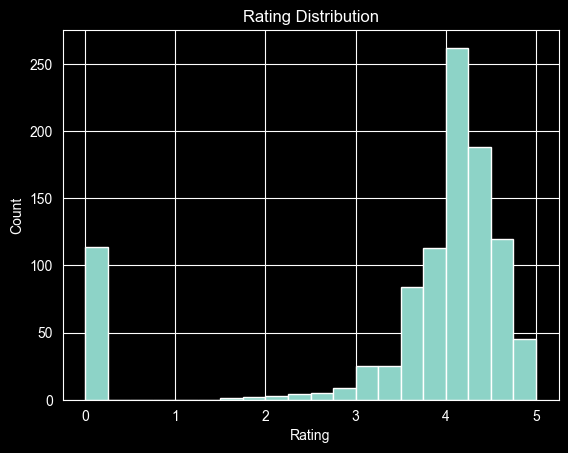

In [21]:
df['rating'].hist(bins=20)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

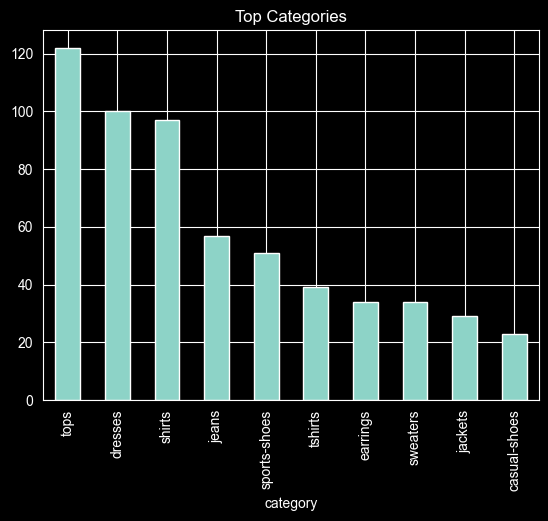

In [22]:
df['category'].value_counts().head(10).plot(kind='bar')

plt.title("Top Categories")
plt.show()

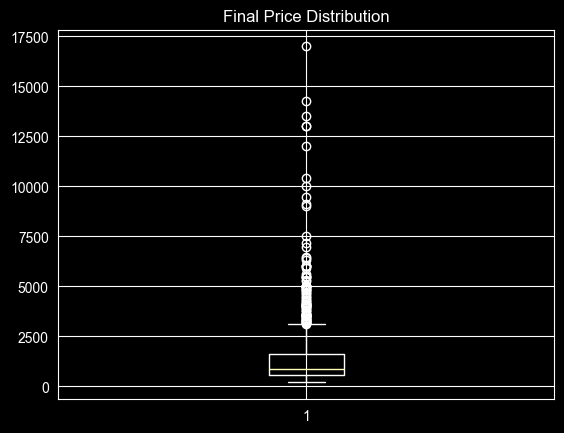

In [23]:
plt.boxplot(df['final_price'].dropna())

plt.title("Final Price Distribution")
plt.show()

In [25]:
print(min(df['final_price']))
print(max(df['final_price']))

199.60000000000002
16999.0


In [24]:
df.to_csv("../data/cleaned_dataset.csv", index=False)

print("Cleaned dataset saved.")

Cleaned dataset saved.


## Key Insights

1. The dataset contains 1000 products with 24 attributes.
2. Missing values of prices were handled using median imputation.
3. Missing values of discount were handled by making them 0.
4. No duplicate records found but code to remove them is implemented.
5. Final price was converted to numeric data from string data. Only for assignment purpose.
6. Final price was replaced by the new price found by applying discount on initial price.
7. Price difference and popularity metrics were created for analysis.
8. Product ratings are concentrated on the higher rating range. Most ratings found between 4 and 4.5
9. Tops is the most common category of products.
10. Price is in the range 200-3000Rs with median lying around 900-1000Rs and outliers go upto 17000Rs.